# Análise de Distribuição — Dataset V7 Adaptativo (DAC)

Este notebook analisa a distribuição de amostras brutas (com duplicatas) e amostras distintas ao longo das diferentes fases do jogo (quantidade de traços preenchidos), utilizando os dados gerados pela arquitetura V7.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Caminho dos dados
DIRETORIO_DADOS = r'D:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\dados\profundidade_minimax_11_adaptativo'
arquivos_npz = glob.glob(os.path.join(DIRETORIO_DADOS, '*.npz'))

print(f"Encontrados {len(arquivos_npz)} arquivos NPZ.")

Encontrados 419 arquivos NPZ.


In [2]:
from collections import defaultdict

# Estruturas para armazenar as contagens
contagem_bruta = defaultdict(int)
estados_vistos = set()
contagem_distinta = defaultdict(int)

print("Lendo arquivos e calculando matrizes únicas. Isso pode levar alguns segundos...")

for arquivo in arquivos_npz:
    try:
        dados = np.load(arquivo, allow_pickle=True)
        estados = dados['estados']
        qtd_tracos = dados['qtd_tracos']
        
        for i in range(len(estados)):
            t = int(qtd_tracos[i])
            contagem_bruta[t] += 1
            
            # Hash simples para identificar unicidade
            estado_bytes = estados[i].tobytes()
            if estado_bytes not in estados_vistos:
                estados_vistos.add(estado_bytes)
                contagem_distinta[t] += 1
                
    except Exception as e:
        print(f"Erro ao processar {arquivo}: {e}")

print(f"Leitura concluída!")
print(f"Total de Amostras Brutas: {sum(contagem_bruta.values()):,}")
print(f"Total de Amostras Distintas: {sum(contagem_distinta.values()):,}")

Lendo arquivos e calculando matrizes únicas. Isso pode levar alguns segundos...
Leitura concluída!
Total de Amostras Brutas: 3,423,460
Total de Amostras Distintas: 2,000,891


In [3]:
# Prepara os dados para o DataFrame
tracos_unicos = sorted(list(set(contagem_bruta.keys()) | set(contagem_distinta.keys())))

df_distribuicao = pd.DataFrame({
    'Quantidade de Traços': tracos_unicos,
    'Amostras Brutas (Total)': [contagem_bruta[t] for t in tracos_unicos],
    'Amostras Distintas (Únicas)': [contagem_distinta[t] for t in tracos_unicos]
})

display(df_distribuicao.head(5))

,Quantidade de Traços,Amostras Brutas (Total),Amostras Distintas (Únicas)
0,1,114116,31
1,2,114116,465
2,3,114116,4495
3,4,114116,30512
4,5,114116,82739


In [4]:
display(df_distribuicao)

,Quantidade de Traços,Amostras Brutas (Total),Amostras Distintas (Únicas)
0,1,114116,31
1,2,114116,465
2,3,114116,4495
3,4,114116,30512
4,5,114116,82739
5,6,114116,105251
6,7,114116,111408
7,8,114116,113203
8,9,114116,113580
9,10,114116,113749


### Gráfico 1: Volume Bruto (Incluindo Duplicadas)
Mostra o esforço total do motor de geração. O eixo Y representa o número total de matrizes simuladas para cada nível de profundidade de jogo (quantidade de traços preenchidos).

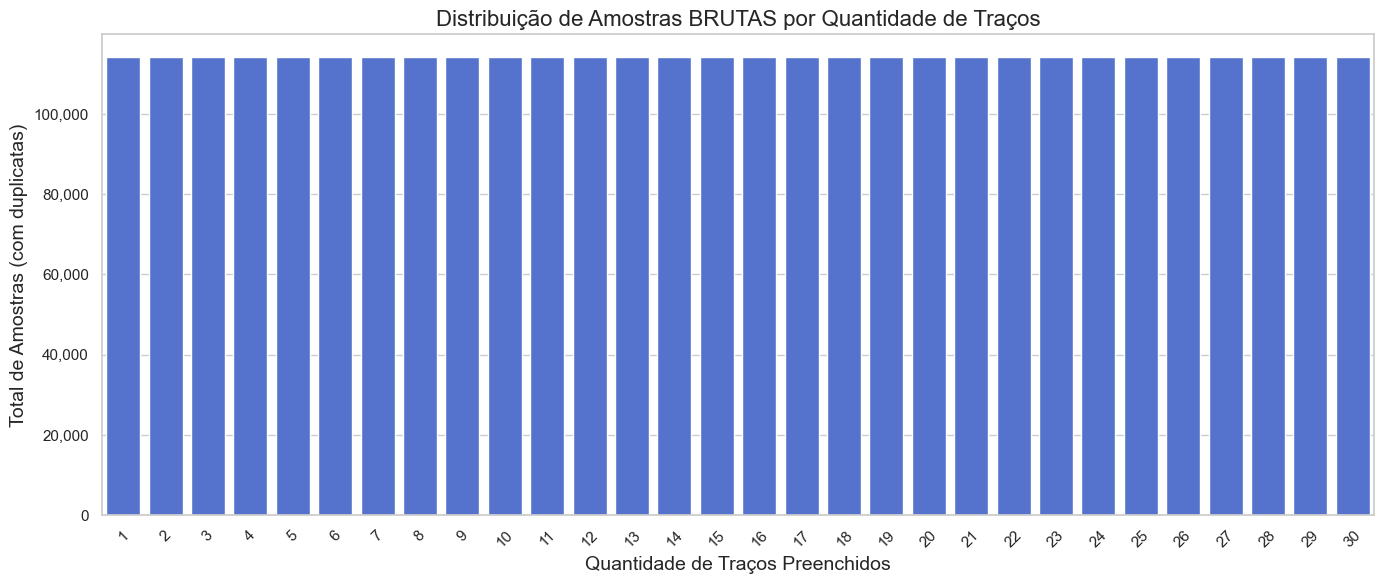

In [5]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_distribuicao, x='Quantidade de Traços', y='Amostras Brutas (Total)', color='royalblue')

plt.title('Distribuição de Amostras BRUTAS por Quantidade de Traços', fontsize=16)
plt.xlabel('Quantidade de Traços Preenchidos', fontsize=14)
plt.ylabel('Total de Amostras (com duplicatas)', fontsize=14)

# Formatar eixo Y com separador de milhar
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Gráfico 2: Matrizes Distintas (Dataset Efetivo da CNN)
Mostra a curva real de aprendizado que será entregue para a CNN treinar, com todas as redundâncias cortadas. Repare que nas extremidades do jogo (como `t=1` ou `t=30`) o número de amostras distintas bate em um teto lógico (saturação do espaço combinatório).

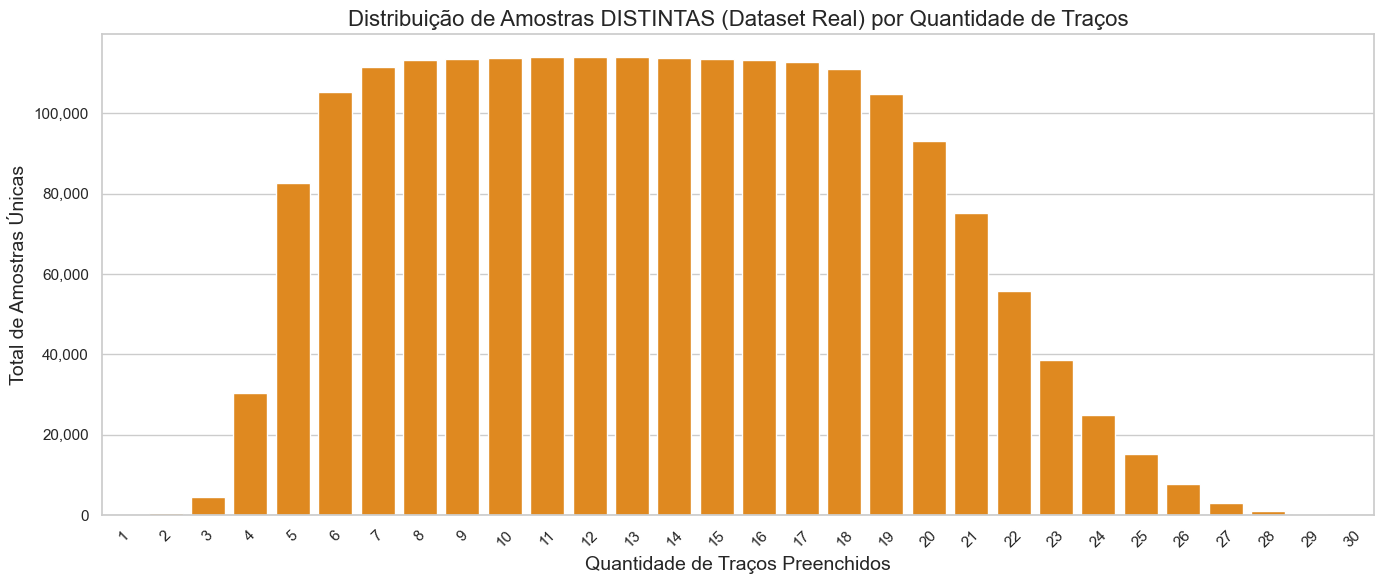

In [6]:
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=df_distribuicao, x='Quantidade de Traços', y='Amostras Distintas (Únicas)', color='darkorange')

plt.title('Distribuição de Amostras DISTINTAS (Dataset Real) por Quantidade de Traços', fontsize=16)
plt.xlabel('Quantidade de Traços Preenchidos', fontsize=14)
plt.ylabel('Total de Amostras Únicas', fontsize=14)

# Formatar eixo Y com separador de milhar
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visões Gerenciais Avançadas

As seções abaixo (canais, conferência de score, cadeias longas) usam **apenas amostras rotuladas** — `depth_melhor_jogada != 0`. Amostras com `depth_melhor_jogada == 0` são NPZs que ainda estavam em rotulação no momento da análise (`melhor_jogada` vazio, scores todos `-1e9`) e são excluídas. **Re-execute o notebook após o fim da rotulação** para cobrir 100% dos dados.

A profundidade de supervisão (`depth_melhor_jogada`) tem dois valores reais: **p=11** (base) e **p=20** (estados de cadeia longa re-rotulados — ver `specs/004-melhoria-geracao-dados-cnn/contracts/npz_schema.md` §3).

In [7]:
# === Carga mestre: le todos os NPZ uma vez e monta `df` (1 linha por amostra rotulada) e `df_dist` (1 linha por tabuleiro distinto) ===
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

INVALIDO = -1e8  # scores invalidos no NPZ valem -1e9

def _to_void(a2d):
    """Cada linha de a2d vira 1 escalar 'void' -> unicidade byte-a-byte (exata e rapida)."""
    a = np.ascontiguousarray(a2d)
    return a.view(np.dtype((np.void, a.dtype.itemsize * a.shape[1]))).reshape(-1)

_arquivos = sorted(glob.glob(os.path.join(DIRETORIO_DADOS, '*.npz')))

board_v, score_v, valset_v, ch_blocks, dens_blocks = [], [], [], [], []
acc = {k: [] for k in ['qtd_tracos', 'depth_mj', 'melhor_jogada', 'qtd_cadeias',
                       'total_caixas', 'tam_max', 'score_min', 'score_max', 'score_2nd', 'n_validos', 'n_top']}
n_brutas = n_nao_rot = 0
_t0 = time.time()
for arq in _arquivos:
    d = np.load(arq, allow_pickle=True)
    dmj = d['depth_melhor_jogada']
    n_brutas += len(dmj)
    rot = dmj != 0
    n_nao_rot += int((~rot).sum())
    if not rot.any():
        continue
    estados = d['estados'][rot]
    scores = d['score_melhor_jogada'][rot]
    canais = d['canais'][rot]
    n = estados.shape[0]
    valid = scores > INVALIDO

    board_v.append(_to_void(estados.reshape(n, -1)))
    score_v.append(_to_void(scores.reshape(n, -1)))
    sorted_padded = np.sort(np.where(valid, scores, np.inf), axis=1).astype(np.float32)
    valset_v.append(_to_void(sorted_padded.reshape(n, -1)))

    acc['qtd_tracos'].append(d['qtd_tracos'][rot])
    acc['depth_mj'].append(dmj[rot])
    acc['melhor_jogada'].append(np.asarray(d['melhor_jogada'][rot], dtype=object))
    acc['qtd_cadeias'].append(d['qtd_cadeias_longas'][rot])
    acc['total_caixas'].append(d['total_caixas_cadeias_longas'][rot])
    acc['tam_max'].append(d['tamanho_max_cadeia_longa'][rot])
    sc = np.where(valid, scores, np.nan)
    acc['score_max'].append(np.nanmax(sc, axis=1).astype(np.float32))
    acc['score_min'].append(np.nanmin(sc, axis=1).astype(np.float32))
    acc['n_validos'].append(valid.sum(axis=1).astype(np.int16))
    _mx = np.nanmax(sc, axis=1, keepdims=True)
    acc['n_top'].append((sc == _mx).sum(axis=1).astype(np.int16))  # arestas empatadas no topo
    segundo = np.sort(np.where(valid, scores, -np.inf), axis=1)[:, -2]
    acc['score_2nd'].append(np.where(np.isfinite(segundo), segundo, np.nan).astype(np.float32))

    ch_blocks.append(canais.any(axis=(1, 2)))                 # (n,12) bool: canal presente em >=1 celula
    dens_blocks.append(canais.sum(axis=(1, 2)).astype(np.int8))  # (n,12): nº de celulas ativas

_, board_id = np.unique(np.concatenate(board_v), return_inverse=True)
_, score_id = np.unique(np.concatenate(score_v), return_inverse=True)
_, valset_id = np.unique(np.concatenate(valset_v), return_inverse=True)
NOMES = list(map(str, np.load(_arquivos[0], allow_pickle=True)['nomes_canais']))
ch_present = np.concatenate(ch_blocks)
ch_dens = np.concatenate(dens_blocks)
del board_v, score_v, valset_v, ch_blocks, dens_blocks

df = pd.DataFrame({
    'board_id': board_id.astype(np.int32),
    'score_id': score_id.astype(np.int32),
    'valset_id': valset_id.astype(np.int32),
    'qtd_tracos': np.concatenate(acc['qtd_tracos']).astype(np.int16),
    'depth_mj': np.concatenate(acc['depth_mj']).astype(np.int16),
    'melhor_jogada': np.concatenate(acc['melhor_jogada']),
    'qtd_cadeias': np.concatenate(acc['qtd_cadeias']).astype(np.int16),
    'total_caixas': np.concatenate(acc['total_caixas']).astype(np.int16),
    'tam_max': np.concatenate(acc['tam_max']).astype(np.int16),
    'score_min': np.concatenate(acc['score_min']),
    'score_max': np.concatenate(acc['score_max']),
    'score_2nd': np.concatenate(acc['score_2nd']),
    'n_validos': np.concatenate(acc['n_validos']).astype(np.int16),
    'n_top': np.concatenate(acc['n_top']).astype(np.int16),
})
df['arestas_livres'] = (31 - df['qtd_tracos']).astype(np.int16)
df['margem'] = df['score_max'] - df['score_2nd']
ch_cols = []
for k, nome in enumerate(NOMES):
    df[f'ch__{nome}'] = ch_present[:, k]
    df[f'dens__{nome}'] = ch_dens[:, k]
    ch_cols.append(f'ch__{nome}')

df_dist = df.drop_duplicates('board_id', keep='first').reset_index(drop=True)

print(f"Amostras brutas totais ...... {n_brutas:,}")
print(f"Nao-rotuladas (excluidas) ... {n_nao_rot:,}  ({100*n_nao_rot/max(n_brutas,1):.1f}%)")
print(f"Amostras rotuladas (df) ..... {len(df):,}")
print(f"Tabuleiros distintos ........ {df['board_id'].nunique():,}")
print(f"Tempo de carga .............. {time.time()-_t0:.1f}s")

Amostras brutas totais ...... 3,423,460
Nao-rotuladas (excluidas) ... 0  (0.0%)
Amostras rotuladas (df) ..... 3,423,460
Tabuleiros distintos ........ 2,000,891
Tempo de carga .............. 12.8s


## 1. Levantamento por Canais

Um canal é considerado **presente** num tabuleiro se está ativo em ≥1 das 12 células (4×3). `Qtd. Amostra` conta amostras brutas (com duplicatas); as demais colunas usam **tabuleiros distintos**. `Media celulas ativas` mostra, quando o canal aparece, em quantas das 12 células ele acende (o canal broadcast `paridade_cadeia_longa_impar` acende nas 12).

In [8]:
linhas = []
for c in ch_cols:
    nome = c[len('ch__'):]
    sub = df_dist[df_dist[c]]
    linhas.append({
        'Canal': nome,
        'Qtd. Amostra': int(df[c].sum()),
        'Qtd. Distintas': int(df_dist[c].sum()),
        'Media de Tracos': round(float(sub['qtd_tracos'].mean()), 2) if len(sub) else 0.0,
        'Tabul. (p=11)': int((sub.depth_mj == 11).sum()),
        'Dist. Melhor Jogada (p=11)': int(sub.loc[sub.depth_mj == 11, 'melhor_jogada'].nunique()),
        'Tabul. (p=20)': int((sub.depth_mj == 20).sum()),
        'Dist. Melhor Jogada (p=20)': int(sub.loc[sub.depth_mj == 20, 'melhor_jogada'].nunique()),
        'Media celulas ativas': round(float(sub[f'dens__{nome}'].mean()), 2) if len(sub) else 0.0,
    })
df_canais = pd.DataFrame(linhas)
display(df_canais)

,Canal,Qtd. Amostra,Qtd. Distintas,Media de Tracos,Tabul. (p=11),Dist. Melhor Jogada (p=11),Tabul. (p=20),Dist. Melhor Jogada (p=20),Media celulas ativas
0,aresta_topo,3255174,1981256,13.57,1940256,31,41000,31,5.21
1,aresta_base,3255352,1981262,13.57,1940258,31,41004,31,5.21
2,aresta_esquerda,3255488,1981435,13.57,1940429,31,41006,31,5.22
3,aresta_direita,3255513,1981280,13.57,1940275,31,41005,31,5.22
4,caixa_fechada,2060567,1103766,17.17,1072315,31,31451,31,2.46
5,eh_grau3,1571037,817342,16.40,800252,31,17090,31,1.29
6,eh_grau2,2937783,1956503,13.67,1915495,31,41008,31,5.31
7,em_cadeia_curta,1194437,959037,15.08,952362,31,6675,31,2.79
8,em_cadeia_longa,1241194,764259,17.83,723251,31,41008,31,4.65
9,em_loop,100862,27161,19.81,27130,31,31,14,4.42


### Como ler esta tabela

- **Qtd. Amostra** — amostras *brutas* (com duplicatas) em que o canal aparece.
- **Qtd. Distintas** — *tabuleiros distintos* em que o canal aparece.
- **Media de Tracos** — em média, em que fase do jogo (quantos traços já preenchidos) o canal costuma aparecer.
- **Tabul. (p=11)** / **Tabul. (p=20)** — quantos *tabuleiros distintos* com o canal foram rotulados em cada profundidade. p=20 recebe só os estados de cadeia longa re-rotulados, por isso é sempre um número pequeno.
- **Dist. Melhor Jogada (p=11 / p=20)** — quantos *rótulos de melhor jogada diferentes* (das 31 arestas possíveis) aparecem entre esses tabuleiros. **Não é contagem de tabuleiros**, e sim quantas arestas distintas chegaram a ser a jogada ótima.

**Por que quase tudo dá 31?** Há 31 arestas possíveis. Para a maioria dos canais o conjunto de tabuleiros é tão grande e variado que *cada uma* das 31 arestas é a melhor jogada em pelo menos um deles → satura em 31. Ou seja: a presença daquele canal **não restringe** a jogada ótima a um subconjunto de arestas.

**Por que `em_loop` em p=20 dá 14 (e não 31)?** Porque o recorte é minúsculo — veja a coluna **Tabul. (p=20)** desse canal: pouquíssimos tabuleiros têm *loop* **e** foram re-rotulados em p=20. Com poucos tabuleiros, só ~14 arestas diferentes chegaram a ser a jogada ótima; não há amostras suficientes para cobrir as 31. É efeito de **tamanho de amostra**, não uma propriedade estrutural do loop.

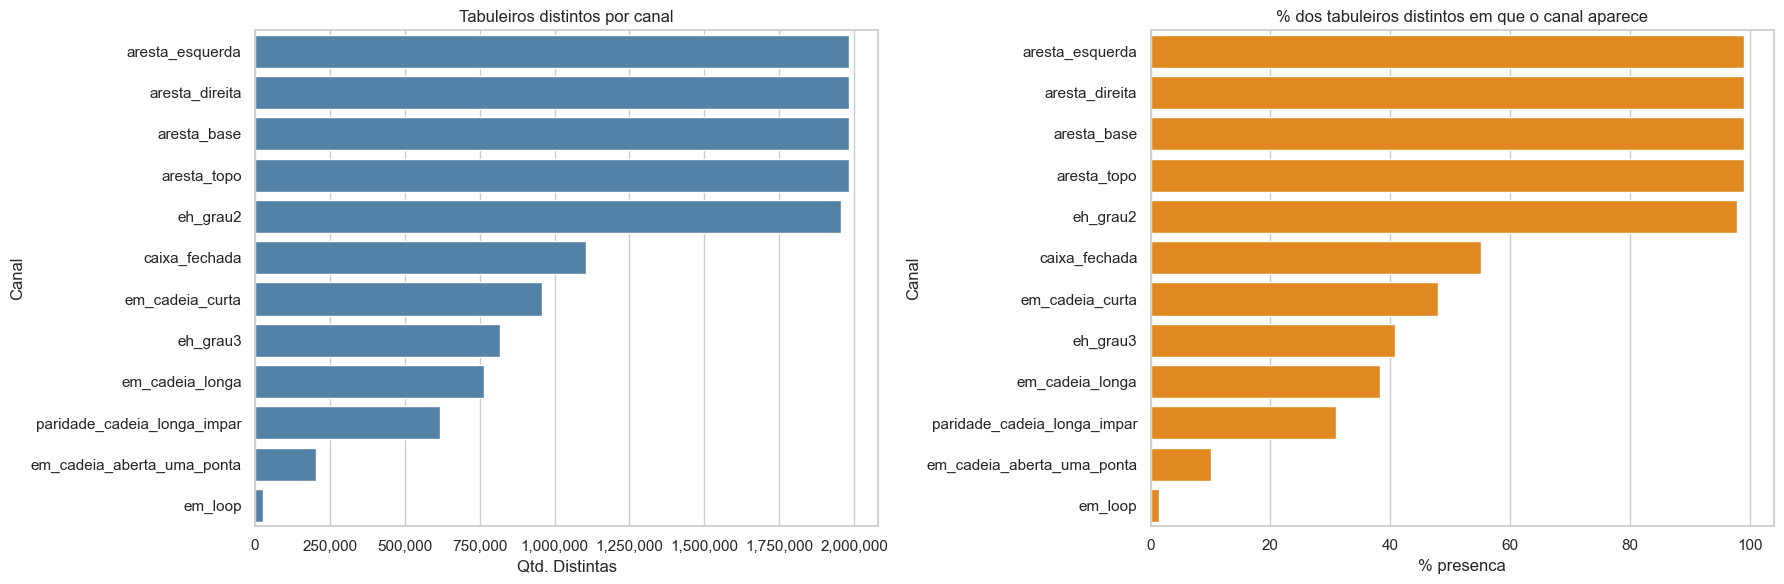

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ordem = df_canais.sort_values('Qtd. Distintas', ascending=False).reset_index(drop=True)
sns.barplot(data=ordem, y='Canal', x='Qtd. Distintas', ax=axes[0], color='steelblue')
axes[0].set_title('Tabuleiros distintos por canal')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ordem['% presenca'] = 100 * ordem['Qtd. Distintas'] / len(df_dist)
sns.barplot(data=ordem, y='Canal', x='% presenca', ax=axes[1], color='darkorange')
axes[1].set_title('% dos tabuleiros distintos em que o canal aparece')
plt.tight_layout(); plt.show()

### Co-ocorrência entre canais

Cada célula = P(canal da linha presente | canal da coluna presente), sobre tabuleiros distintos. Leia por coluna: "dado que o canal X aparece, com que frequência o canal Y também aparece?".

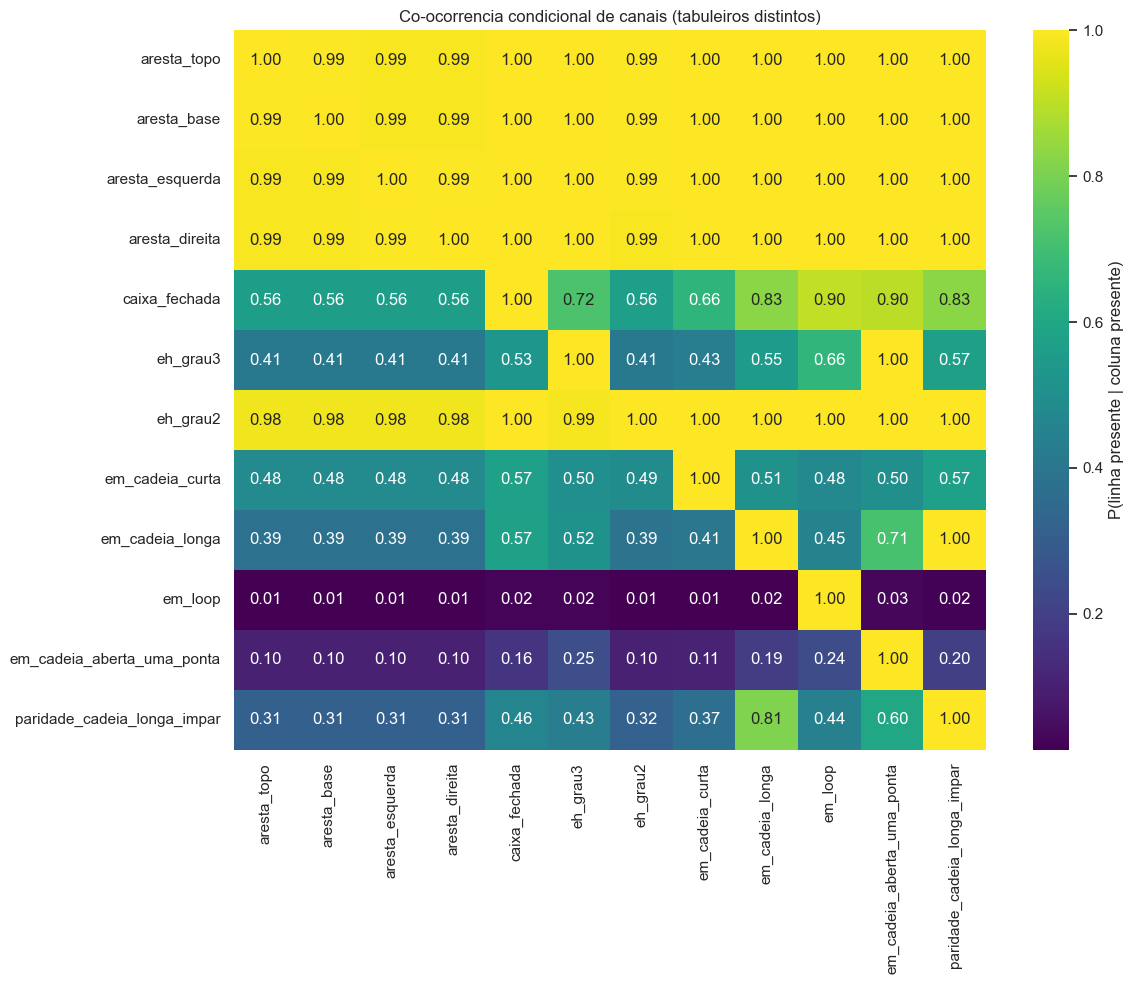

In [10]:
M = df_dist[ch_cols].values.astype(bool)
base = M.sum(axis=0)
co = np.zeros((len(NOMES), len(NOMES)))
for i in range(len(NOMES)):
    for j in range(len(NOMES)):
        co[i, j] = (M[:, i] & M[:, j]).sum() / base[j] if base[j] else 0.0
plt.figure(figsize=(12, 10))
sns.heatmap(pd.DataFrame(co, index=NOMES, columns=NOMES), annot=True, fmt='.2f',
            cmap='viridis', cbar_kws={'label': 'P(linha presente | coluna presente)'})
plt.title('Co-ocorrencia condicional de canais (tabuleiros distintos)')
plt.tight_layout(); plt.show()

### Ativação dos canais por fase do jogo

Fração dos tabuleiros distintos de cada fase (`qtd_tracos`) em que o canal aparece. Revela *quando* cada estrutura emerge ao longo da partida (ex.: cadeias longas e meias-pontas só surgem no fim).

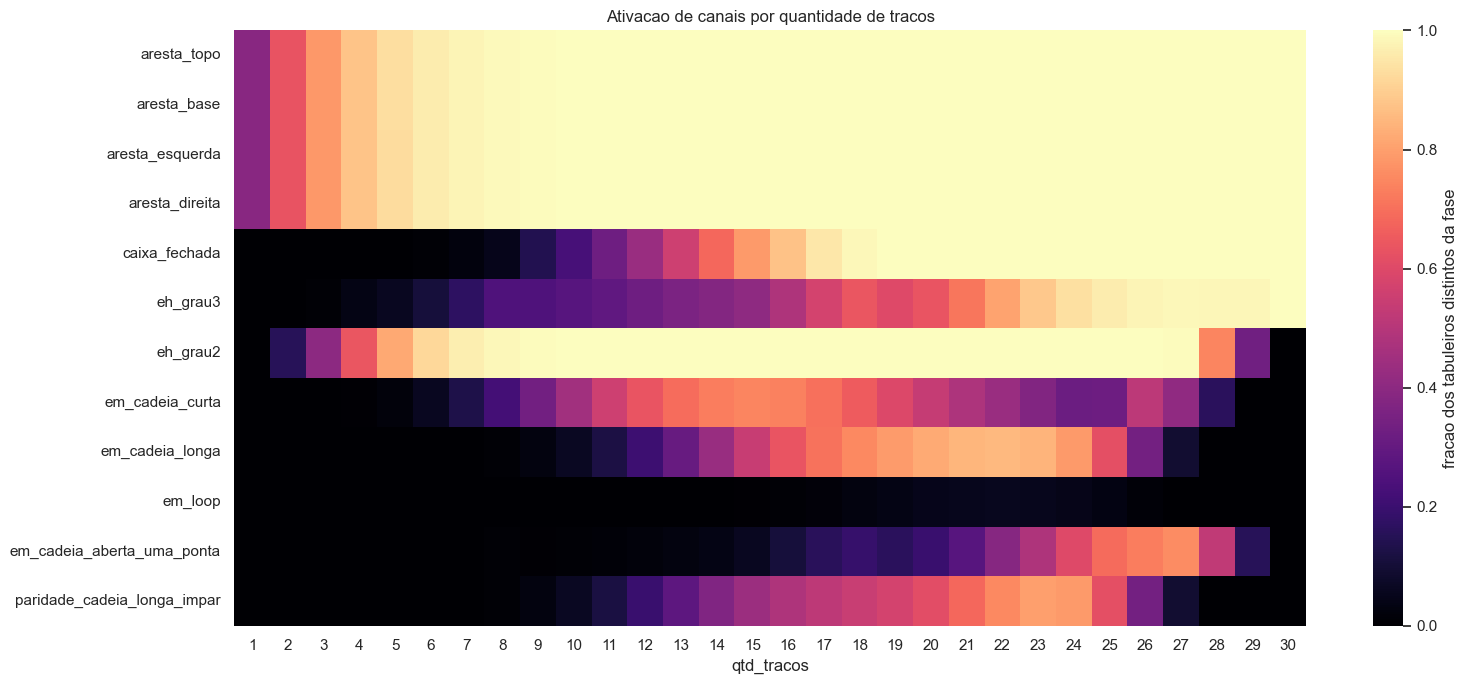

In [11]:
fases = sorted(df_dist['qtd_tracos'].unique())
mat = np.zeros((len(NOMES), len(fases)))
for fi, t in enumerate(fases):
    sub = df_dist[df_dist['qtd_tracos'] == t]
    for ki, c in enumerate(ch_cols):
        mat[ki, fi] = sub[c].mean() if len(sub) else 0.0
plt.figure(figsize=(16, 7))
sns.heatmap(pd.DataFrame(mat, index=NOMES, columns=fases), cmap='magma',
            cbar_kws={'label': 'fracao dos tabuleiros distintos da fase'})
plt.title('Ativacao de canais por quantidade de tracos')
plt.xlabel('qtd_tracos'); plt.tight_layout(); plt.show()

## 2. Conferência de `score_melhor_jogada`

Usando apenas pares distintos `(tabuleiro, score)`:
- **Item 1** — para um dado vetor `score_melhor_jogada`, quantos tabuleiros distintos o possuem? (intuição: pouquíssimos)
- **Item 2** — para um dado tabuleiro, quantos vetores `score_melhor_jogada` distintos existem? (esperado: exatamente 1 — Minimax é determinístico para uma profundidade fixa)

In [12]:
pares = df[['board_id', 'score_id']].drop_duplicates()
por_board = pares.groupby('board_id')['score_id'].nunique()
por_score = pares.groupby('score_id')['board_id'].nunique()

print("ITEM 2 - determinismo (1 tabuleiro -> N scores)")
print(f"  Tabuleiros distintos ................. {por_board.shape[0]:,}")
print(f"  Com >1 score distinto (anomalias) .... {int((por_board > 1).sum()):,}")
print(f"  Maximo de scores p/ um tabuleiro ..... {int(por_board.max())}")
print()
print("ITEM 1 - coincidencia (1 score -> N tabuleiros)")
print(f"  Vetores de score distintos ........... {por_score.shape[0]:,}")
print(f"  Compartilhados por >1 tabuleiro ...... {int((por_score > 1).sum()):,}")
print(f"  Maximo de tabuleiros p/ um score ..... {int(por_score.max())}")
print()
print("=> Bijecao perfeita: cada vetor score_melhor_jogada identifica 1 unico tabuleiro,")
print("   e cada tabuleiro tem exatamente 1 vetor. O score e uma 'impressao digital' do estado.")

# Visao relaxada: ignora a POSICAO da jogada; compara so o conjunto (multiset) de valores de score.
por_vs = df[['board_id', 'valset_id']].drop_duplicates().groupby('valset_id')['board_id'].nunique()
em_colisao = int(por_vs[por_vs > 1].sum())
print("\nVISAO RELAXADA - ignorando a posicao da jogada (so o conjunto de valores de score):")
print(f"  Conjuntos de valores distintos ....... {por_vs.shape[0]:,}")
print(f"  Conjuntos com >1 tabuleiro ........... {int((por_vs > 1).sum()):,}")
print(f"  Tabuleiros distintos em colisao ...... {em_colisao:,} ({100*em_colisao/len(df_dist):.1f}%)")
print("  -> A unicidade vem da GEOMETRIA (quais arestas estao livres), nao dos valores.")

ITEM 2 - determinismo (1 tabuleiro -> N scores)
  Tabuleiros distintos ................. 2,000,891
  Com >1 score distinto (anomalias) .... 0
  Maximo de scores p/ um tabuleiro ..... 1

ITEM 1 - coincidencia (1 score -> N tabuleiros)
  Vetores de score distintos ........... 2,000,891
  Compartilhados por >1 tabuleiro ...... 0
  Maximo de tabuleiros p/ um score ..... 1

=> Bijecao perfeita: cada vetor score_melhor_jogada identifica 1 unico tabuleiro,
   e cada tabuleiro tem exatamente 1 vetor. O score e uma 'impressao digital' do estado.

VISAO RELAXADA - ignorando a posicao da jogada (so o conjunto de valores de score):
  Conjuntos de valores distintos ....... 172,582
  Conjuntos com >1 tabuleiro ........... 96,898
  Tabuleiros distintos em colisao ...... 1,925,207 (96.2%)
  -> A unicidade vem da GEOMETRIA (quais arestas estao livres), nao dos valores.


### Entendendo a "visão relaxada"

O `score_melhor_jogada` é um vetor de 31 posições, uma por **aresta específica** do tabuleiro. Posições de arestas já jogadas valem `-1e9` (inválidas); as livres carregam o Q-value do Minimax.

- **Itens 1 e 2 (exatos)** comparam o vetor **inteiro**, incluindo *em qual posição* cada valor está. Deu bijeção — cada vetor pertence a exatamente 1 tabuleiro. Faz sentido: *quais* posições estão livres já descreve a geometria do tabuleiro.
- **Visão relaxada** joga fora a posição e olha só o **conjunto de valores** (ex.: "este tabuleiro tem os scores {+2, +2, 0, −1}", sem dizer em quais arestas).

O que ela revela: **~96% dos tabuleiros distintos compartilham seu conjunto de valores com algum outro tabuleiro**. Isto é, os *números* de score se repetem muitíssimo entre tabuleiros diferentes — o que torna cada vetor único **não são os valores, e sim onde eles estão** (a geometria das arestas livres).

Lendo a saída da célula acima:
- `Conjuntos de valores distintos` — quantos "sacos de números" diferentes existem (bem menos que o nº de tabuleiros).
- `Conjuntos com >1 tabuleiro` — quantos desses sacos são compartilhados por 2+ tabuleiros.
- `Tabuleiros distintos em colisão` — quantos tabuleiros caem em algum saco compartilhado (~96%).

## 3. Cadeias Longas

Visão sobre os campos escalares `qtd_cadeias_longas`, `total_caixas_cadeias_longas` e `tamanho_max_cadeia_longa` (tabuleiros distintos). `prof_min = total_caixas + 2·qtd_cadeias` é a profundidade Minimax mínima para resolver o estado corretamente; estados com `prof_min > 11` têm rótulos potencialmente subótimos em p=11 e são candidatos à re-rotulação em p=20 (ver `npz_schema.md`).

Distribuicao do numero de cadeias longas (tabuleiros distintos):
  0 cadeia(s):  1,236,632  (61.80%)
  1 cadeia(s):    614,931  (30.73%)
  2 cadeia(s):    146,058  ( 7.30%)
  3 cadeia(s):      3,270  ( 0.16%)

Tabuleiros com >=1 cadeia longa .... 764,259 (38.2%)
Media de caixas por cadeia ......... 3.94
prof_min > 11 (subotimos em p=11) .. 54,148 (2.71%)
Tabuleiros re-rotulados em p=20 .... 41,008


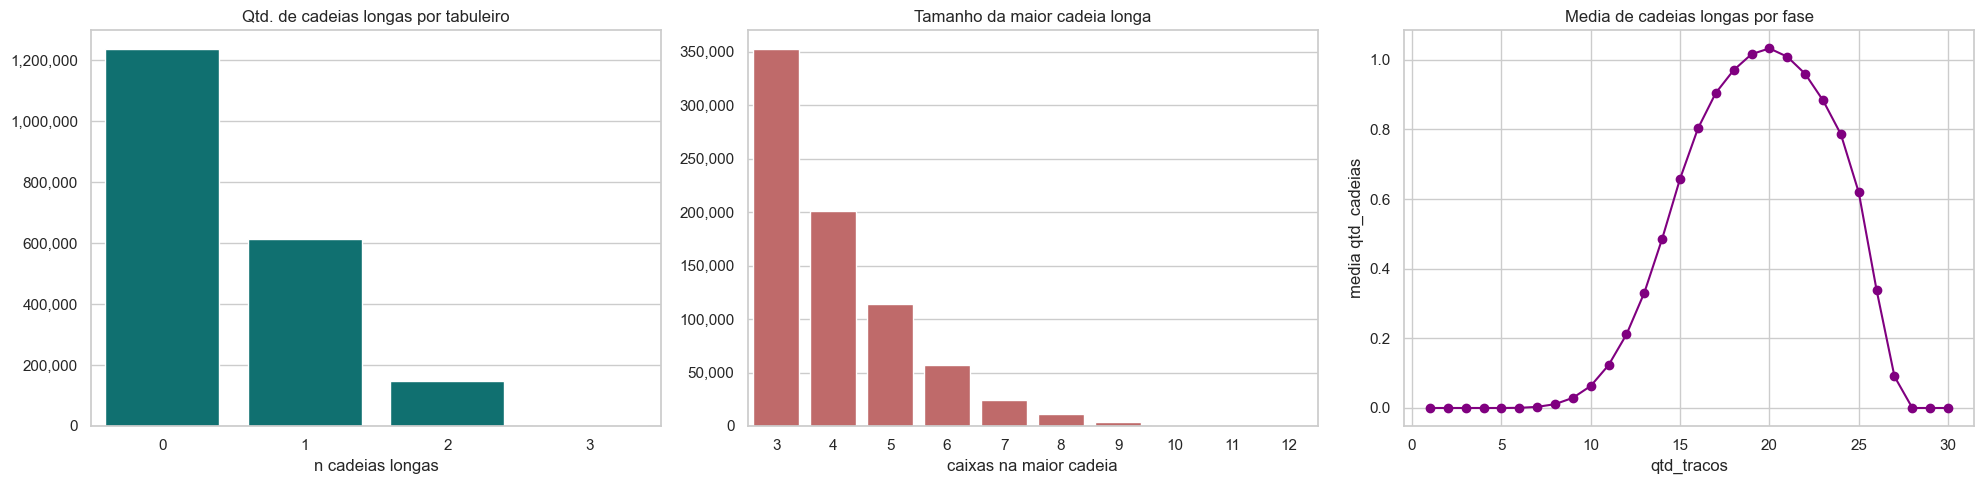

In [13]:
dd = df_dist.copy()
dd['prof_min'] = dd['total_caixas'] + 2 * dd['qtd_cadeias']
tot = len(dd)

print("Distribuicao do numero de cadeias longas (tabuleiros distintos):")
vc = dd['qtd_cadeias'].value_counts().sort_index()
for k, v in vc.items():
    print(f"  {k} cadeia(s): {v:>10,}  ({100*v/tot:5.2f}%)")
com = dd[dd['qtd_cadeias'] > 0]
print(f"\nTabuleiros com >=1 cadeia longa .... {len(com):,} ({100*len(com)/tot:.1f}%)")
print(f"Media de caixas por cadeia ......... {(com['total_caixas']/com['qtd_cadeias']).mean():.2f}")
print(f"prof_min > 11 (subotimos em p=11) .. {int((dd['prof_min']>11).sum()):,} ({100*(dd['prof_min']>11).mean():.2f}%)")
print(f"Tabuleiros re-rotulados em p=20 .... {int((dd['depth_mj']==20).sum()):,}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(x=vc.index, y=vc.values, ax=axes[0], color='teal')
axes[0].set_title('Qtd. de cadeias longas por tabuleiro'); axes[0].set_xlabel('n cadeias longas')
tm = com['tam_max'].value_counts().sort_index()
sns.barplot(x=tm.index, y=tm.values, ax=axes[1], color='indianred')
axes[1].set_title('Tamanho da maior cadeia longa'); axes[1].set_xlabel('caixas na maior cadeia')
pc = dd.groupby('qtd_tracos')['qtd_cadeias'].mean()
axes[2].plot(pc.index, pc.values, marker='o', color='purple')
axes[2].set_title('Media de cadeias longas por fase'); axes[2].set_xlabel('qtd_tracos'); axes[2].set_ylabel('media qtd_cadeias')
for a in axes[:2]:
    a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()

### Em todo estado com cadeia longa, o Minimax enxergou até o fechamento completo das cadeias?

Este era o objetivo de passar a usar p=20 nos estados de cadeia longa. A verificação abaixo é direta e **não importa qual profundidade foi usada** (11 ou 20) — importa só se ela foi suficiente para ver as cadeias fecharem.

Um estado com cadeia longa (`qtd_cadeias_longas ≥ 1`) é considerado **coberto** se a profundidade usada satisfaz **pelo menos um** destes critérios:
- **Enxergou até o fim do jogo:** `depth_melhor_jogada ≥ arestas_livres`. Se o Minimax vê o encerramento do jogo, logicamente vê o fechamento de todas as cadeias.
- **Profundidade ≥ prof_min:** `depth_melhor_jogada ≥ prof_min`, onde `prof_min = total_caixas + 2·qtd_cadeias` é a profundidade que resolve corretamente as cadeias (`npz_schema.md`).

Qualquer estado que falhe nos **dois** critérios seria uma cadeia longa cujo fechamento o Minimax não chegou a enxergar — e apareceria listado abaixo.

In [14]:
cad = df_dist[df_dist['qtd_cadeias'] >= 1].copy()
cad['prof_min'] = cad['total_caixas'] + 2 * cad['qtd_cadeias']
cad['viu_fim'] = cad['depth_mj'] >= cad['arestas_livres']    # enxergou ate o fim do jogo
cad['viu_cadeias'] = cad['depth_mj'] >= cad['prof_min']      # profundidade suficiente p/ resolver as cadeias
cad['coberto'] = cad['viu_fim'] | cad['viu_cadeias']

n = len(cad); n_ok = int(cad['coberto'].sum()); n_falha = n - n_ok
print(f"Estados distintos COM cadeia longa (qtd_cadeias_longas >= 1) .. {n:,}")
print(f"  Minimax enxergou ate o fechamento das cadeias ............. {n_ok:,} ({100*n_ok/n:.3f}%)")
print(f"  NAO enxergou (cadeia longa com rotulo subotimo) ........... {n_falha:,}")
print()
print("Como cada estado foi coberto:")
print(f"  enxergou ate o fim do jogo (depth >= arestas_livres) ...... {int(cad['viu_fim'].sum()):,}")
print(f"  profundidade >= prof_min .................................. {int(cad['viu_cadeias'].sum()):,}")
print(f"  re-rotulados em p=20 (subconjunto) ........................ {int((cad['depth_mj'] == 20).sum()):,}")

if n_falha == 0:
    print("\n=> SIM. Em 100% dos estados com cadeia longa o Minimax que definiu a melhor")
    print("   jogada enxergou ate o fechamento completo das cadeias. Objetivo do p=20 atingido.")
else:
    print("\n=> ATENCAO: ha estados com cadeia longa NAO cobertos. Amostra:")
    display(cad.loc[~cad['coberto'], ['qtd_tracos', 'arestas_livres', 'depth_mj',
                                      'qtd_cadeias', 'total_caixas', 'prof_min']].head(20))

Estados distintos COM cadeia longa (qtd_cadeias_longas >= 1) .. 764,259
  Minimax enxergou ate o fechamento das cadeias ............. 764,259 (100.000%)
  NAO enxergou (cadeia longa com rotulo subotimo) ........... 0

Como cada estado foi coberto:
  enxergou ate o fim do jogo (depth >= arestas_livres) ...... 293,192
  profundidade >= prof_min .................................. 751,119
  re-rotulados em p=20 (subconjunto) ........................ 41,008

=> SIM. Em 100% dos estados com cadeia longa o Minimax que definiu a melhor
   jogada enxergou ate o fechamento completo das cadeias. Objetivo do p=20 atingido.


## 4. Faixa de Score (máx/mín) por profundidade e traços faltando

`arestas_livres = 31 − qtd_tracos` = traços que ainda faltam preencher. Para cada (profundidade, arestas livres), o maior e o menor valor de `score_melhor_jogada`.

> **Por que p=11 chega a MAX = 12, se "só olha 11 lances à frente"?** (sua dúvida)
>
> Quando `arestas_livres ≤ 11`, faltam no máximo 11 lances até o **fim do jogo** — então a busca de profundidade 11 **alcança os nós terminais** e enxerga o placar final real, não um valor truncado. Dois motivos fazem 11 lances renderem até 12 caixas de diferença:
> 1. **Regra do lance extra:** fechar uma caixa dá outro lance ao mesmo jogador. Logo "11 lances" *não* são 11 jogadas alternadas — um jogador pode encadear vários lances seguidos e capturar uma cadeia inteira enquanto o adversário não joga.
> 2. **Um traço pode fechar 2 caixas de uma vez** (a aresta compartilhada entre duas caixas de grau 3). Então 11 traços conseguem fechar até 12 caixas.
>
> A prova está no próprio gráfico: o **+12 só aparece em `arestas_livres ≤ 11`**. A partir de `arestas_livres = 12` (faltam 12 lances > profundidade 11), o p=11 **deixa de alcançar o fim** e seu MAX cai; já o p=20, que ainda chega ao terminal nessa faixa, continua mostrando 12.
>
> **Observação:** o domínio empírico é **[-12, 12]** — diferente do `[-6, 6]` declarado em `npz_schema.md` §1.2 (vale revisar o contrato).

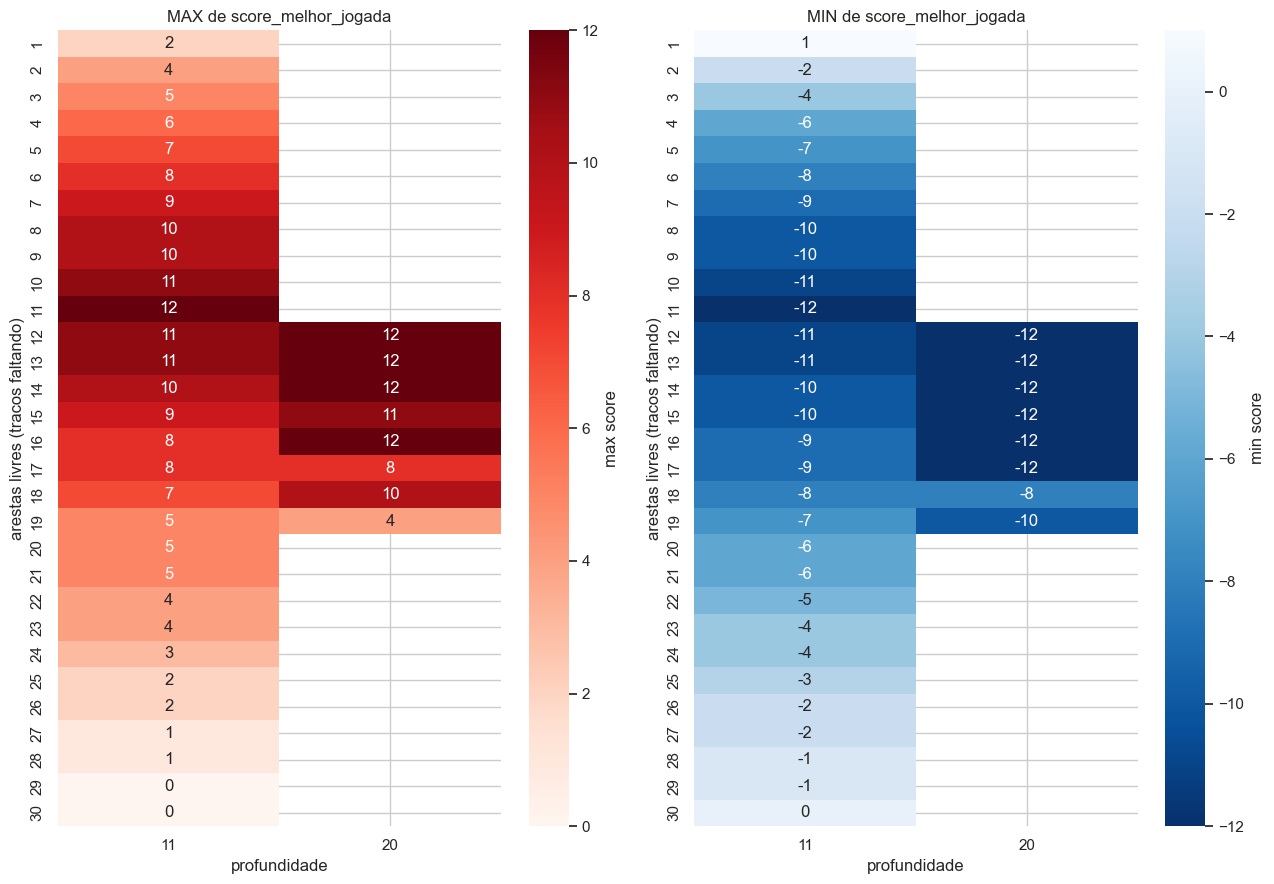

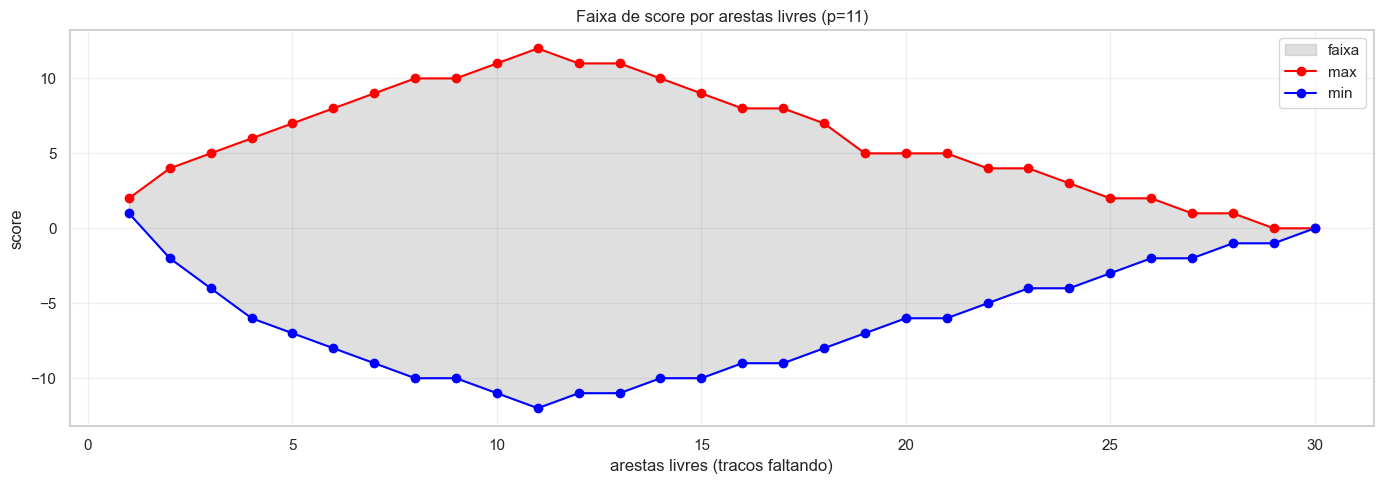

In [15]:
piv_max = df.pivot_table(index='arestas_livres', columns='depth_mj', values='score_max', aggfunc='max')
piv_min = df.pivot_table(index='arestas_livres', columns='depth_mj', values='score_min', aggfunc='min')
fig, axes = plt.subplots(1, 2, figsize=(13, 9))
sns.heatmap(piv_max, annot=True, fmt='.0f', cmap='Reds', ax=axes[0], cbar_kws={'label': 'max score'})
axes[0].set_title('MAX de score_melhor_jogada')
sns.heatmap(piv_min, annot=True, fmt='.0f', cmap='Blues_r', ax=axes[1], cbar_kws={'label': 'min score'})
axes[1].set_title('MIN de score_melhor_jogada')
for a in axes:
    a.set_xlabel('profundidade'); a.set_ylabel('arestas livres (tracos faltando)')
plt.tight_layout(); plt.show()

g = df[df['depth_mj'] == 11].groupby('arestas_livres').agg(maxv=('score_max', 'max'), minv=('score_min', 'min'))
plt.figure(figsize=(14, 5))
plt.fill_between(g.index, g['minv'], g['maxv'], alpha=0.25, color='gray', label='faixa')
plt.plot(g.index, g['maxv'], marker='o', color='red', label='max')
plt.plot(g.index, g['minv'], marker='o', color='blue', label='min')
plt.title('Faixa de score por arestas livres (p=11)')
plt.xlabel('arestas livres (tracos faltando)'); plt.ylabel('score'); plt.legend()
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 5. Visões Adicionais Propostas

Views que não estavam na lista original mas são relevantes para o treino da CNN:

1. **Balanceamento dos rótulos (`melhor_jogada`)** — distribuição da classe-alvo. Desbalanceamento sugere uso de `class_weight`.
2. **Margem de decisão e empates** — `score_max − score_2nd`. Quando = 0 há ≥2 jogadas ótimas empatadas e o alvo *argmax* é arbitrário. Como **~61% dos estados com >1 jogada têm empate**, há forte argumento para *soft targets* (treinar contra a distribuição de scores) e para avaliar *top-k* em vez de acerto exato do argmax.
3. **Eficiência do gerador por fase** — razão distintas/brutas: quanto de simulação é "desperdiçado" em duplicatas em cada fase.

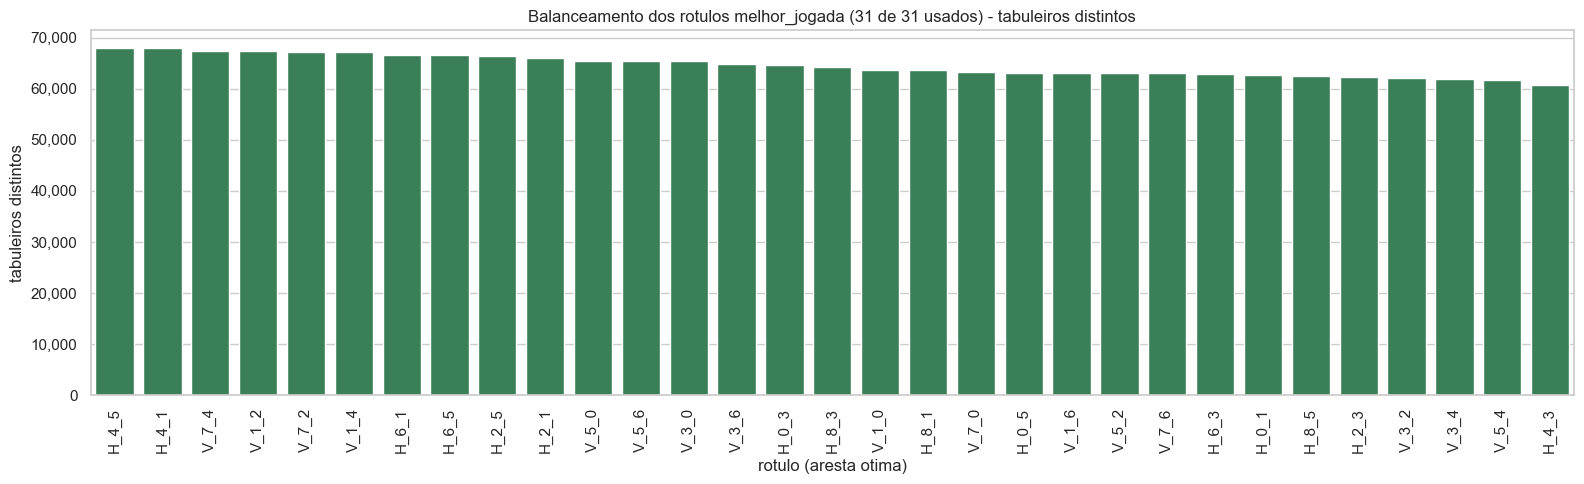

Razao de frequencia entre o rotulo mais e o menos comum: 1.12x


In [16]:
vc = df_dist['melhor_jogada'].value_counts()
plt.figure(figsize=(16, 5))
sns.barplot(x=vc.index, y=vc.values, color='seagreen')
plt.title(f'Balanceamento dos rotulos melhor_jogada ({vc.shape[0]} de 31 usados) - tabuleiros distintos')
plt.xticks(rotation=90); plt.ylabel('tabuleiros distintos'); plt.xlabel('rotulo (aresta otima)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()
print(f"Razao de frequencia entre o rotulo mais e o menos comum: {vc.max()/vc.min():.2f}x")

Estados com >1 jogada valida ...... 3,309,346
  com empate exato (margem=0) ..... 2,005,082 (60.6%)
  margem media .................... 1.38
  margem mediana .................. 0.0


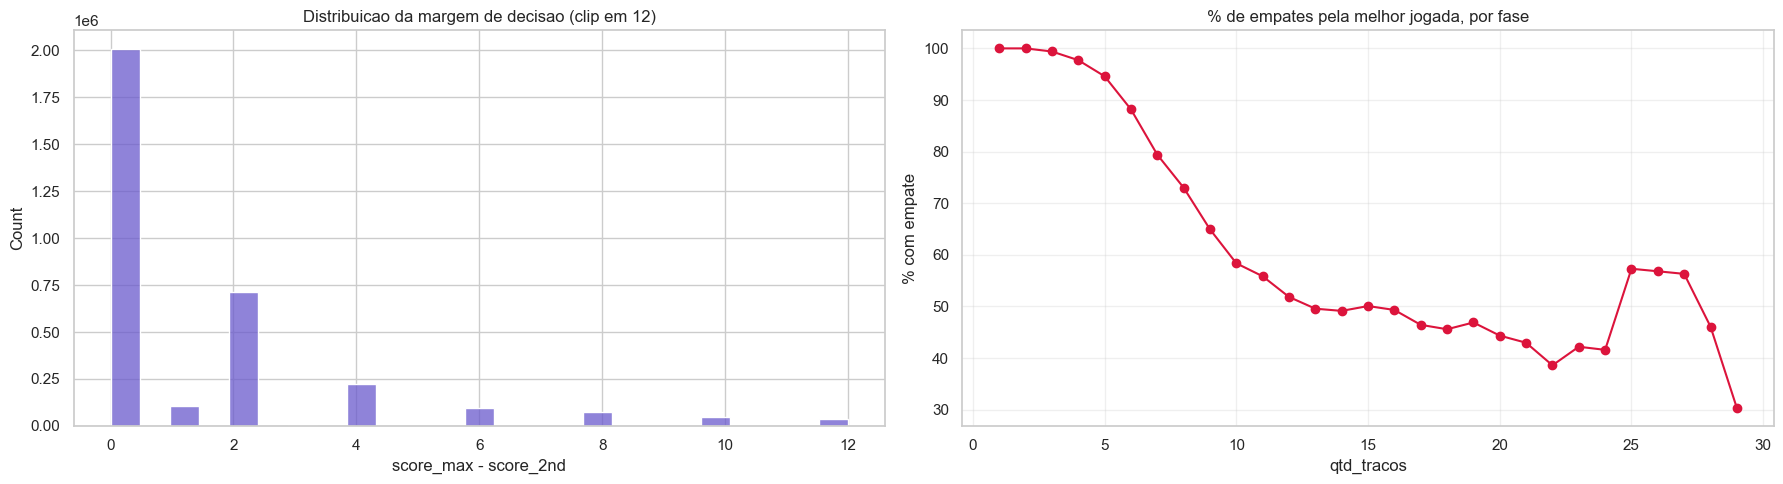

In [17]:
multi = df[df['n_validos'] > 1].copy()
multi['empate'] = multi['margem'] == 0
print(f"Estados com >1 jogada valida ...... {len(multi):,}")
print(f"  com empate exato (margem=0) ..... {int(multi['empate'].sum()):,} ({100*multi['empate'].mean():.1f}%)")
print(f"  margem media .................... {multi['margem'].mean():.2f}")
print(f"  margem mediana .................. {multi['margem'].median():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.histplot(multi['margem'].clip(upper=12), bins=25, ax=axes[0], color='slateblue')
axes[0].set_title('Distribuicao da margem de decisao (clip em 12)')
axes[0].set_xlabel('score_max - score_2nd')
taxa = multi.groupby('qtd_tracos')['empate'].mean()
axes[1].plot(taxa.index, 100 * taxa.values, marker='o', color='crimson')
axes[1].set_title('% de empates pela melhor jogada, por fase')
axes[1].set_xlabel('qtd_tracos'); axes[1].set_ylabel('% com empate'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

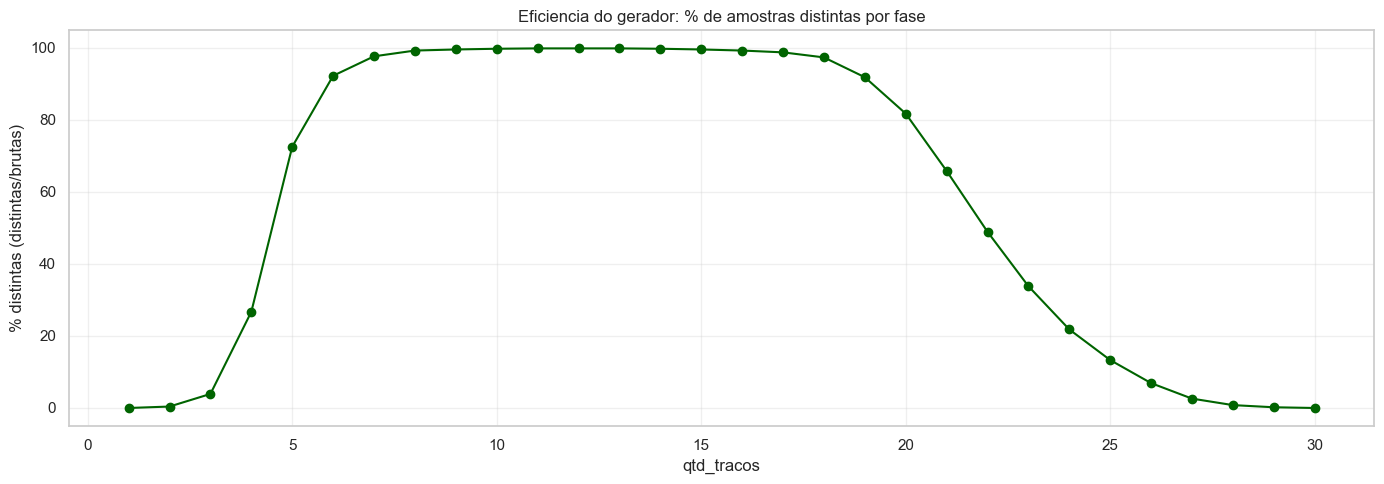

,brutas,distintas,% distintas
qtd_tracos,,,
1,114116,31,0.0
2,114116,465,0.4
3,114116,4495,3.9
4,114116,30512,26.7
5,114116,82739,72.5
6,114116,105251,92.2
7,114116,111408,97.6
8,114116,113203,99.2
9,114116,113580,99.5


In [18]:
bruta = df.groupby('qtd_tracos').size()
dist = df_dist.groupby('qtd_tracos').size()
red = pd.DataFrame({'brutas': bruta, 'distintas': dist})
red['% distintas'] = (100 * red['distintas'] / red['brutas']).round(1)
plt.figure(figsize=(14, 5))
plt.plot(red.index, red['% distintas'], marker='o', color='darkgreen')
plt.title('Eficiencia do gerador: % de amostras distintas por fase')
plt.xlabel('qtd_tracos'); plt.ylabel('% distintas (distintas/brutas)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
display(red)

### Média de arestas empatadas em 1º lugar, por fase

Para cada tabuleiro distinto, conta quantas arestas atingem o **maior** valor de `score_melhor_jogada` — isto é, quantas jogadas são *co-ótimas* (empatadas em 1º lugar). O gráfico mostra a média dessa contagem por `qtd_tracos`. Complementa a visão de empates: aqui medimos *quantas* jogadas empatam no topo, não só se há empate. Apenas amostras distintas.

Interpretação: no início (poucos traços) o tabuleiro é quase simétrico e muitas arestas são equivalentes; a contagem cai no meio-jogo (decisões mais "amarradas") e volta a 1 no fim (resta 1 jogada).

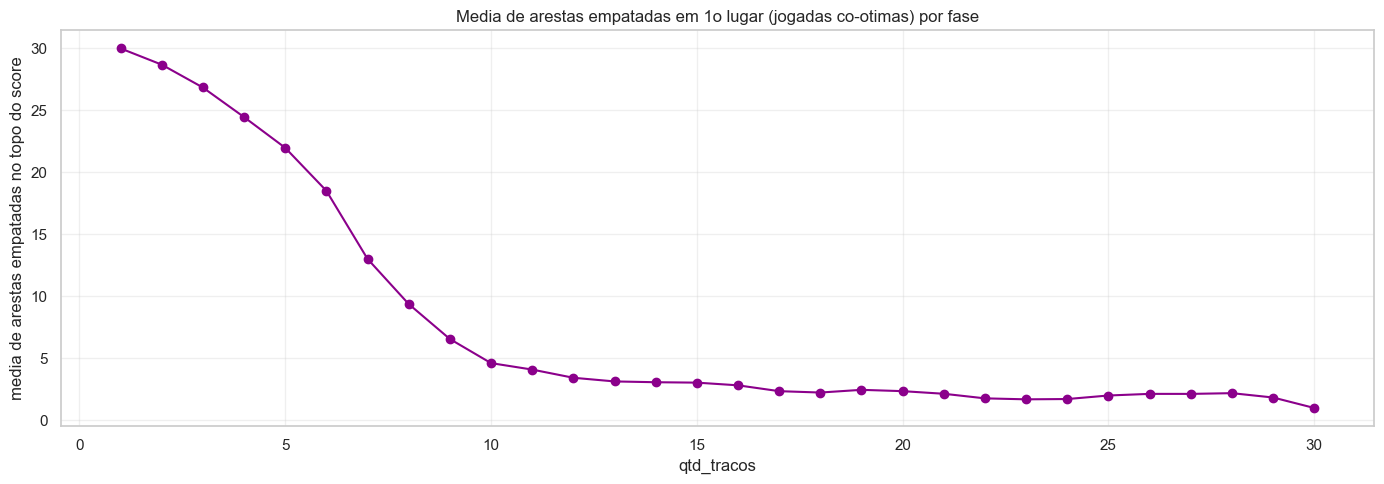

,mean,median,max
qtd_tracos,,,
1,30.00,30.0,30
2,28.69,29.0,29
3,26.85,28.0,28
4,24.46,25.0,27
5,21.98,24.0,26
6,18.52,21.0,25
7,13.03,16.0,24
8,9.39,11.0,23
9,6.56,4.0,22


In [19]:
g = df_dist.groupby('qtd_tracos')['n_top'].mean()
plt.figure(figsize=(14, 5))
plt.plot(g.index, g.values, marker='o', color='darkmagenta')
plt.title('Media de arestas empatadas em 1o lugar (jogadas co-otimas) por fase')
plt.xlabel('qtd_tracos'); plt.ylabel('media de arestas empatadas no topo do score')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
display(df_dist.groupby('qtd_tracos')['n_top'].agg(['mean', 'median', 'max']).round(2))